In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from CurveFit import plot_data, continuity_conditions, concavity_conditions, unpack_coeffs

In [11]:
data = pd.read_csv('./Beamed_data_11102025/202565_N2_5mm.csv').sort_values(by='p_MKS(Torr)')

/var/folders/36/k342r5bs1qn0khj_k754ypyw0000gn/T/ipykernel_26257/2819824757.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


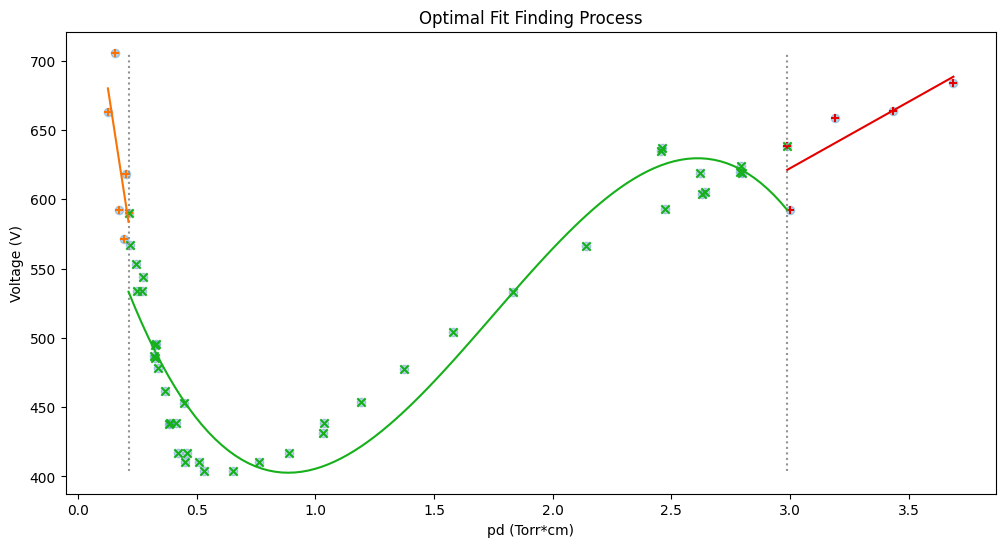

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches((12,6))
ax.set(xlabel='pd (Torr*cm)', ylabel='Voltage (V)', title='Optimal Fit Finding Process')
p = data.iloc[:,5].values
d = data.iloc[:,8].values
v = data.iloc[:,3].values
p_d = np.array(p*d)

ax.scatter(p_d, v, alpha=0.3)

leftNode = 5
rightNode = -5

# draw lines at the nodes where I want the lines to meet
ax.vlines((p_d[leftNode], p_d[rightNode]), v.min(), v.max(), colors='xkcd:grey', linestyles=':')

# divide the data set along those lines
# splitting  arrays is not open sets. The left side is open and incl
leftlinearpd = p_d[:leftNode+1]
middlepd = p_d[leftNode:rightNode+1]
rightlinearpd = p_d[rightNode:]

# print(f"{len(leftlinearpd[-2:])} | {len(middlepd[:2])}")
# print(f"{leftlinearpd}, {p_d[leftNode]}")
# print(f"{leftlinearpd[-2:]}, {middlepd[:2]}")
# print(f"{p_d[leftNode]}, {middlepd}")

# print(f"{len(middlepd[-2:])} | {len(rightlinearpd[:2])}")
# print(f"{middlepd}, {p_d[rightNode]}")
# print(f"{middlepd[-2:]}, {rightlinearpd[:2]}")
# print(f"{p_d[rightNode]}, {rightlinearpd}")

leftlinearv = v[:leftNode+1]
middlev = v[leftNode:rightNode+1]
rightlinearv = v[rightNode:]


ax.scatter(leftlinearpd, leftlinearv, marker='+', color = 'xkcd:orange')
ax.scatter(middlepd, middlev, marker='x', color = 'xkcd:green')
ax.scatter(rightlinearpd, rightlinearv, marker='+', color = 'xkcd:red')

polyLeft = np.polyfit(leftlinearpd, leftlinearv, 1)
polyMid = np.polyfit(middlepd, middlev, 3)
polyRight = np.polyfit(rightlinearpd, rightlinearv, 1)

# test range of points to ensure we are ending/starting on same node
#ax.plot(np.concatenate([leftlinearpd[-2:], middlepd[:2]]), np.concatenate([leftlinearv[-2:], middlev[:2]]))
#ax.set_xlim([0.15,0.25])
#ax.set_xlim([2.75,3.25])

x1 = np.linspace(leftlinearpd[0], leftlinearpd[-1], 100, endpoint=True)
x2 = np.linspace(middlepd[0], middlepd[-1], 100)
x3 = np.linspace(rightlinearpd[0], rightlinearpd[-1], 100)

y1 = np.zeros_like(x1)
y2 = np.zeros_like(x2)
y3 = np.zeros_like(x3)

for i,x in enumerate(x1):
    y1[i] = np.polyval(polyLeft, x)
for i,x in enumerate(x2):
    y2[i] = np.polyval(polyMid, x)
for i,x in enumerate(x3):
    y3[i] = np.polyval(polyRight, x)

x = np.concatenate([x1,x2,x3])
y = np.concatenate([y1,y2,y3])

nodepointsx = [leftlinearpd[0], leftlinearpd[-1], middlepd[0], middlepd[-1], rightlinearpd[0], rightlinearpd[-1]]
nodepointsy = [leftlinearv[0], leftlinearv[-1], middlev[0], middlev[-1], rightlinearv[0], rightlinearv[-1]]

#ax.scatter(nodepointsx, nodepointsy, color = 'xkcd:red')
ax.plot(x1,y1, color = 'xkcd:orange')
ax.plot(x2,y2, color = 'xkcd:green')
ax.plot(x3,y3, color = 'xkcd:red')

# print(f"left node: {x1[-1]} | {x2[0]}")
# print(f"left node: {leftlinearpd[-1]} | {middlepd[0]}")
# print(f"left node: {round(leftlinearpd[-1],1)} | {round(middlepd[0],1)}")

fig.show()



array([0.12534568, 0.15609871, 0.17227194, 0.19242873, 0.19991781])

/var/folders/36/k342r5bs1qn0khj_k754ypyw0000gn/T/ipykernel_26257/89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
